# DEMO DIVRS — Khử thiên lệch (ML-10M)

So sánh **DIVRS** với baseline. **Tự dùng MF** (nếu đã train, lưu trên Drive) làm baseline; chưa có MF thì dùng **Most-Popular**.
**KHÔNG cần GPU**. Gồm: (A) bảng Recall/HR/NDCG, (B) đường cong độ phổ biến, (C) **web demo** đánh dấu 👁️train / ✅test.

## 1. Setup: code + data + Drive

In [25]:
!pip install -q faiss-cpu gradio matplotlib
import os, glob, re
REPO='/content/DIVRS'
if os.path.exists(REPO):
    !cd {REPO} && git fetch -q origin && git reset --hard -q origin/main
else:
    !git clone -q https://github.com/HatDuaa/DIVRS-reproduce.git {REPO}
%cd {REPO}
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/ml10m/output/train_coo_record.npz'):
    !cd data && wget -q https://raw.githubusercontent.com/tsinghua-fib-lab/DICE/main/data/ml10m.zip && unzip -oq ml10m.zip
from google.colab import drive; drive.mount('/content/drive')
OUT_DIR='/content/drive/MyDrive/Colab Notebooks/DIVRS_output'

/content/DIVRS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Nạp embedding DIVRS + baseline (MF nếu có, không thì Most-Popular)

In [26]:
import numpy as np, scipy.sparse as sp, torch
D='data/ml10m/output/'
train=sp.load_npz(D+'train_coo_record.npz').tocsr()
test =sp.load_npz(D+'test_coo_record.npz').tocsr()
pop  =np.load(D+'popularity.npy').astype(float)
n_user,n_item=train.shape
pop_pct=pop.argsort().argsort()/(len(pop)-1)

def best_ckpt(run):
    cks=glob.glob(run+'ckpt/epoch_*.pth')
    best_ep,best_rc=None,-1
    for lf in glob.glob(run+'log/*'):
        try: txt=open(lf,encoding='utf-8',errors='ignore').read()
        except Exception: continue
        for m in re.finditer(r"VALIDATION epoch: (\d+).*?'recall': np\.float64\(([\d.]+)\)", txt):
            ep,rc=int(m.group(1)),float(m.group(2))
            if rc>best_rc: best_rc,best_ep=rc,ep
    if best_ep is not None and os.path.exists(run+f'ckpt/epoch_{best_ep}.pth'):
        return run+f'ckpt/epoch_{best_ep}.pth', best_ep, round(best_rc,4)
    mx=max(cks,key=lambda x:int(re.findall(r'epoch_(\d+)',x)[0]))
    return mx, int(re.findall(r'epoch_(\d+)',mx)[0]), None

div_runs=[r for r in glob.glob(OUT_DIR+'/*/') if 'divrs' in r.lower() and glob.glob(r+'ckpt/epoch_*.pth')]
assert div_runs, 'Khong thay run DIVRS nao co checkpoint tren Drive!'
div_run=max(div_runs, key=lambda r: len(glob.glob(r+'ckpt/epoch_*.pth')))
sd=torch.load(best_ckpt(div_run)[0],map_location='cpu')
Ud=sd['users_iv'].float().numpy(); Id=sd['items_iv'].float().numpy()
def score_divrs(u): return Ud[u] @ Id.T
print('DIVRS run:',os.path.basename(div_run.rstrip('/')))

mf_runs=[r for r in glob.glob(OUT_DIR+'/*/') if 'divrs' not in r.lower() and glob.glob(r+'ckpt/epoch_*.pth')]
BASE_NAME=None
if mf_runs:
    mf_run=max(mf_runs,key=lambda r:len(glob.glob(r+'ckpt/epoch_*.pth')))
    sdm=torch.load(best_ckpt(mf_run)[0],map_location='cpu')
    if 'users' in sdm:
        Umf=sdm['users'].float().numpy(); Imf=sdm['items'].float().numpy()
        def score_base(u): return Umf[u]@Imf.T
        BASE_NAME='MF (baseline hoc that)'; print('Baseline = MF:',os.path.basename(mf_run.rstrip('/')))
if BASE_NAME is None:
    def score_base(u): return pop
    BASE_NAME='Most-Popular (baseline)'; print('Baseline = Most-Popular (chua co MF)')

MODELS={BASE_NAME:score_base, 'DIVRS (debiased)':score_divrs}
print('embedding DIVRS:',Ud.shape,'| users',n_user,'items',n_item)

DIVRS run: ml10m-DIVRS-0.8-cause-0.2-Res-debug_2026-06-16-16-32-50
Baseline = Most-Popular (chua co MF)
embedding DIVRS: (37962, 128) | users 37962 items 4819


## A. Bảng so sánh — Recall / HR / NDCG + Độ phổ biến (proxy IOU)
Eval CHUẨN: loại phim đã xem (train) rồi đo trên test. Đây mới là số đánh giá.

In [27]:
def evaluate(score_fn,k=20,n_eval=2000):
    users=np.where(np.diff(test.indptr)>0)[0][:n_eval]
    rec,hr,ndcg,popm=[],[],[],[]
    idcg_cache={}
    for u in users:
        s=np.array(score_fn(u),dtype=float); s[train[u].indices]=-1e9
        top=np.argsort(-s)[:k]
        tset=set(test[u].indices)
        hits=[1 if it in tset else 0 for it in top]
        nh=sum(hits)
        rec.append(nh/max(len(tset),1))
        hr.append(1.0 if nh>0 else 0.0)
        dcg=sum(h/np.log2(i+2) for i,h in enumerate(hits))
        m=min(len(tset),k); idcg=idcg_cache.get(m) or sum(1/np.log2(i+2) for i in range(m)); idcg_cache[m]=idcg
        ndcg.append(dcg/idcg if idcg>0 else 0.0)
        popm.append(pop_pct[top].mean())
    return np.mean(rec),np.mean(hr),np.mean(ndcg),np.mean(popm)

print(f"{'Model':<26}{'Recall@20':>11}{'HR@20':>9}{'NDCG@20':>10}{'AvgPop%':>10}")
for name,fn in MODELS.items():
    r,h,n,p=evaluate(fn)
    print(f'{name:<26}{r:>11.4f}{h:>9.4f}{n:>10.4f}{p*100:>9.1f}%')
print('\n=> DIVRS: Recall/HR/NDCG cao hon, AvgPop% thap hon = chinh xac hon va it thien lech hon.')

Model                       Recall@20    HR@20   NDCG@20   AvgPop%
Most-Popular (baseline)        0.0622   0.1885    0.0375     99.7%
DIVRS (debiased)               0.2651   0.6270    0.1502     92.1%

=> DIVRS: Recall/HR/NDCG cao hon, AvgPop% thap hon = chinh xac hon va it thien lech hon.


## B. Đường cong: độ phổ biến TB của gợi ý theo Top-K (thấp = khử thiên lệch tốt)

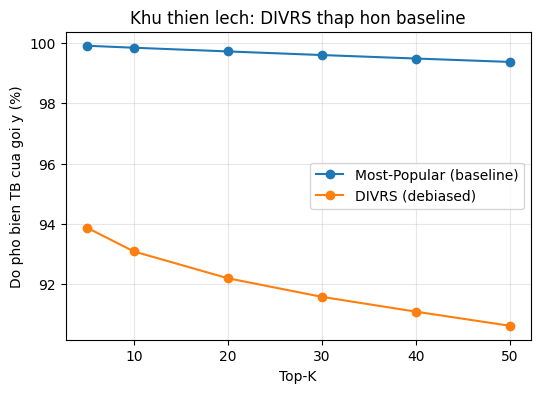

Da luu debias_curve.png


In [28]:
import matplotlib.pyplot as plt
Ks=[5,10,20,30,40,50]
plt.figure(figsize=(6,4))
for name,fn in MODELS.items():
    y=[evaluate(fn,k=k,n_eval=1000)[3]*100 for k in Ks]
    plt.plot(Ks,y,marker='o',label=name)
plt.xlabel('Top-K'); plt.ylabel('Do pho bien TB cua goi y (%)')
plt.title('Khu thien lech: DIVRS thap hon baseline'); plt.legend(); plt.grid(alpha=.3)
plt.savefig('debias_curve.png',dpi=120,bbox_inches='tight'); plt.show()
print('Da luu debias_curve.png')

## C. WEB DEMO — slider trên, 2 ô dưới cạnh nhau, căn cột monospace
Hiện TẤT CẢ: 👁️ đã xem (train) / ✅ sẽ xem (test) / — mới. Top-K tới 50, ô cao cố định + cuộn trong ô.

In [29]:
import gradio as gr
GOOD=np.argsort(-np.diff(test.indptr))[:30].tolist()
print('User ID nen thu (nhieu phim test):', GOOD[:12])
base_label, div_label = list(MODELS.keys())

def reco(uid,k):
    uid=int(uid); k=int(k)
    seen=set(train[uid].indices); watched=set(test[uid].indices); res=[]
    for name,fn in MODELS.items():
        s=np.array(fn(uid),dtype=float)
        top=np.argsort(-s)[:k]                      # khong mask -> hien tat ca
        lines=[]
        for r,it in enumerate(top):
            tr='✓' if it in seen else '✗'
            te='✓' if it in watched else '✗'
            lines.append(f'#{r+1:>3} | Item {it:<5} | pho bien:{pop_pct[it]*100:>4.0f}% | predict ✓ | train {tr} | test {te}')
        nh=len(set(top)&watched); ns=len(set(top)&seen)
        head=f'>>> TEST(✅):{nh}   TRAIN(👁️):{ns}   moi:{k-nh-ns}   | pho bien TB:{pop_pct[top].mean()*100:.0f}%'
        res.append(head+'\n'+'-'*48+'\n'+'\n'.join(lines))
    return res[0],res[1]

CSS='.mono textarea{font-family:monospace!important;font-size:13px;line-height:1.35;white-space:pre;}'
with gr.Blocks(css=CSS, title='DIVRS Debiasing Demo') as demo:
    gr.Markdown('## DIVRS Debiasing Demo — ML-10M\n'
                '👁️ da xem (train)  ·  ✅ se xem (test, dap an giau)  ·  — moi.  Hien tat ca, khong an train.')
    with gr.Row():
        uid=gr.Slider(0,n_user-1,step=1,value=int(GOOD[0]),label='User ID (thu cac so in o tren)')
        kk =gr.Slider(5,50,step=1,value=20,label='Top-K')
    with gr.Row():
        ob=gr.Textbox(label=base_label,lines=16,max_lines=16,elem_classes='mono')
        od=gr.Textbox(label=div_label, lines=16,max_lines=16,elem_classes='mono')
    for c in (uid,kk): c.change(reco,[uid,kk],[ob,od])
    demo.load(reco,[uid,kk],[ob,od])
demo.launch(share=True)

User ID nen thu (nhieu phim test): [6818, 3590, 3478, 3591, 3149, 2848, 2797, 2891, 7277, 11176, 6661, 2353]


/tmp/ipykernel_7915/805116870.py:24: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title='DIVRS Debiasing Demo') as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://979b2945aabd921a1e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Ghi chú
- Web demo **hiện hết** (cả train) chỉ để xem; **metric ở mục A vẫn loại train** (đúng chuẩn đánh giá).
- ✅ = phim trong **tập test (giấu)** — mẫu phim user xem, không phải toàn bộ. **Không-✅ ≠ user sẽ không xem**.
- Số **chính thức cho báo cáo** lấy từ `eval_checkpoint.ipynb`. `AvgPop%` = proxy IOU.